### 1.Load the Two Datasets to be merged

In [17]:
import pandas as pd

stock_df = pd.read_csv(
    r"C:\Users\dhama\Desktop\MarketPulse_NLP\stock_processed.csv"
)

sentiment_df = pd.read_csv(
    r"C:\Users\dhama\Desktop\MarketPulse_NLP\daily_sentiment.csv"
)

### 2.Convert Date from both datasets to datetime

In [18]:
stock_df["Date"] = pd.to_datetime(
    stock_df["Date"]
)

sentiment_df["Date"] = pd.to_datetime(
    sentiment_df["Date"]
)

### 3.Date Range Check

In [19]:
print(stock_df["Date"].min())
print(stock_df["Date"].max())

print(sentiment_df["Date"].min())
print(sentiment_df["Date"].max())

2020-01-02 00:00:00
2024-12-31 00:00:00
2020-01-02 00:00:00
2024-03-04 00:00:00


### 6.Merge Datasets

In [20]:
merged_df = pd.merge(
    stock_df,
    sentiment_df,
    on="Date",
    how="left"
)

In [21]:
merged_df = merged_df[merged_df["Date"] <= "2024-03-04"].reset_index(drop=True)


In [22]:
print(merged_df.shape)
merged_df.head()

(10481, 14)


,Date,Open,High,Low,Close,Volume,Stock,Sector,Daily_Return,MA_7,MA_30,Price_Range,Volatility_7,sentiment_score
0,2020-01-02,71.344062,72.394093,71.091191,72.333885,135480400,AAPL,Technology,NaN,NaN,NaN,1.302902,NaN,-0.066060
1,2020-01-03,71.563190,72.389242,71.406651,71.630623,146322800,AAPL,Technology,-0.9722,NaN,NaN,0.982591,NaN,0.100800
2,2020-01-06,70.754028,72.239958,70.503561,72.201424,118387200,AAPL,Technology,0.7969,NaN,NaN,1.736396,NaN,0.070340
3,2020-01-07,72.211041,72.466322,71.642681,71.861839,108872000,AAPL,Technology,-0.4703,NaN,NaN,0.823641,NaN,0.006975
4,2020-01-08,71.565629,73.318885,71.565629,73.017845,132079200,AAPL,Technology,1.6087,NaN,NaN,1.753256,NaN,0.045533


### 7.Null Check

In [23]:
merged_df["sentiment_score"].isnull().sum()

np.int64(120)

In [24]:
merged_df["sentiment_score"] = (
    merged_df["sentiment_score"]
    .fillna(0)
)

In [25]:
merged_df[
    ["Date","Stock","Daily_Return","sentiment_score"]
].head(20)

,Date,Stock,Daily_Return,sentiment_score
0,2020-01-02,AAPL,NaN,-0.066060
1,2020-01-03,AAPL,-0.9722,0.100800
2,2020-01-06,AAPL,0.7969,0.070340
3,2020-01-07,AAPL,-0.4703,0.006975
4,2020-01-08,AAPL,1.6087,0.045533
5,2020-01-09,AAPL,2.1241,-0.222729
6,2020-01-10,AAPL,0.2260,0.212300
7,2020-01-13,AAPL,2.1364,0.090300
8,2020-01-14,AAPL,-1.3503,0.283600
9,2020-01-15,AAPL,-0.4286,0.152729


In [26]:
merged_df.to_csv(
    r"C:\Users\dhama\Desktop\MarketPulse NLP\merged_stock_sentiment.csv",
    index=False
)

In [27]:
merged_df.isnull().sum()

Date                 0
Open                 0
High                 0
Low                  0
Close                0
Volume               0
Stock                0
Sector               0
Daily_Return        10
MA_7                60
MA_30              290
Price_Range          0
Volatility_7        70
sentiment_score      0
dtype: int64

In [28]:
merged_df = merged_df.dropna()

In [29]:
print(merged_df.shape)

(10191, 14)


In [30]:
merged_df.describe()

,Date,Open,High,Low,Close,Volume,Daily_Return,MA_7,MA_30,Price_Range,Volatility_7,sentiment_score
count,10191,10191.000000,10191.000000,10191.000000,10191.000000,1.019100e+04,10191.000000,10191.000000,10191.000000,10191.000000,10191.000000,10191.000000
mean,2022-02-21 09:35:48.130703616,139.979631,141.751978,138.172714,140.012708,8.139930e+07,0.107094,139.745723,138.729655,3.579264,2.052245,0.039253
min,2020-02-13 00:00:00,4.982962,5.228001,4.499358,4.890824,4.601000e+05,-22.124800,5.296200,6.157200,0.108758,0.146575,-0.633500
25%,2021-02-18 00:00:00,54.769459,55.442807,53.782141,54.525000,9.125250e+06,-1.027800,54.490150,53.382800,1.294582,1.127279,-0.040727
50%,2022-02-22 00:00:00,133.916776,135.474558,132.197724,133.971024,2.243400e+07,0.055100,134.109900,133.722500,2.366734,1.639308,0.033557
75%,2023-02-28 00:00:00,187.725941,189.736208,185.263018,187.685966,7.074370e+07,1.203050,187.149200,185.254300,4.578963,2.470381,0.119897
max,2024-03-04 00:00:00,412.544402,414.496674,407.178709,412.534637,1.543911e+09,24.369600,404.687000,400.314900,54.326660,15.007580,0.709600
std,NaN,95.700851,96.892549,94.467751,95.713782,1.509545e+08,2.508007,95.491760,94.682643,3.717748,1.469110,0.142161


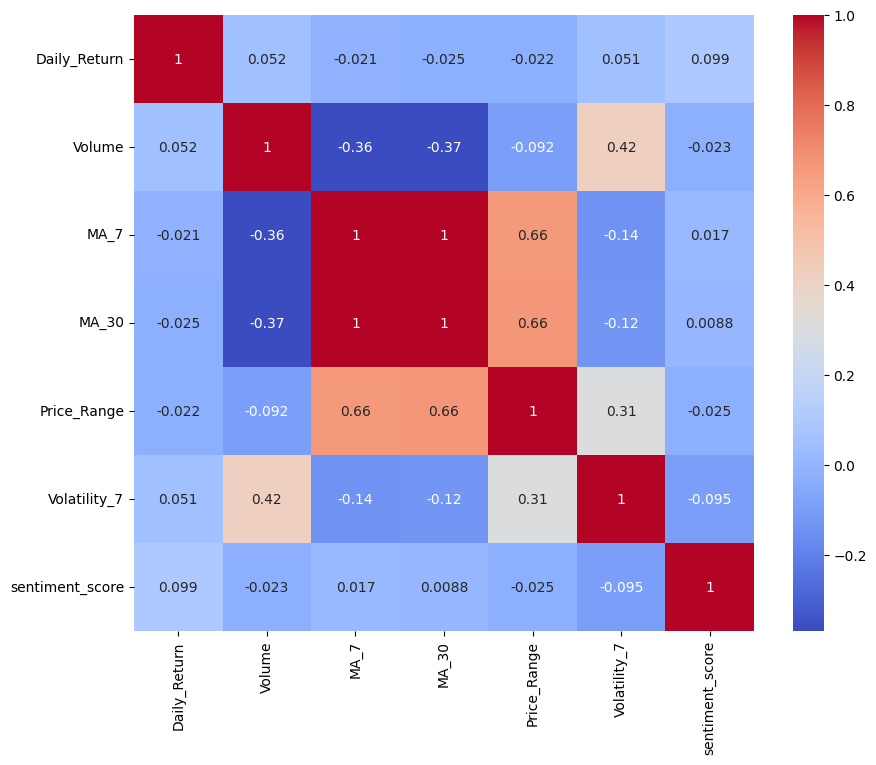

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    merged_df[
        [
            "Daily_Return",
            "Volume",
            "MA_7",
            "MA_30",
            "Price_Range",
            "Volatility_7",
            "sentiment_score"
        ]
    ].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [32]:
merged_df[
    ["Daily_Return", "sentiment_score"]
].corr()

,Daily_Return,sentiment_score
Daily_Return,1.000000,0.098802
sentiment_score,0.098802,1.000000


In [33]:
for sector in merged_df["Sector"].unique():

    temp = merged_df[
        merged_df["Sector"] == sector
    ]

    corr = temp[
        ["Daily_Return", "sentiment_score"]
    ].corr().iloc[0,1]

    print(f"{sector}: {corr:.4f}")

Technology: 0.0821
Energy: 0.1116
Financial: 0.1664
Healthcare: 0.0735


In [34]:
def sentiment_category(score):
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

merged_df["Sentiment_Category"] = (
    merged_df["sentiment_score"]
    .apply(sentiment_category)
)

In [35]:
merged_df.groupby("Sentiment_Category")[
    "Daily_Return"
].mean()

Sentiment_Category
Negative   -0.274538
Neutral     0.061048
Positive    0.329077
Name: Daily_Return, dtype: float64

In [36]:
merged_df.to_csv(
    r"C:\Users\dhama\Desktop\MarketPulse NLP\merged_stock_sentiment_final.csv",
    index=False
)